Using device: cpu


100%|██████████| 9.91M/9.91M [00:03<00:00, 2.51MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 118kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]


Epoch [1/30] | D Loss: 0.0471 | G Loss: 9.5198
Epoch [2/30] | D Loss: 0.3771 | G Loss: 3.3784
Epoch [3/30] | D Loss: 0.6225 | G Loss: 3.1684
Epoch [4/30] | D Loss: 0.3744 | G Loss: 2.9697
Epoch [5/30] | D Loss: 0.3155 | G Loss: 3.0146


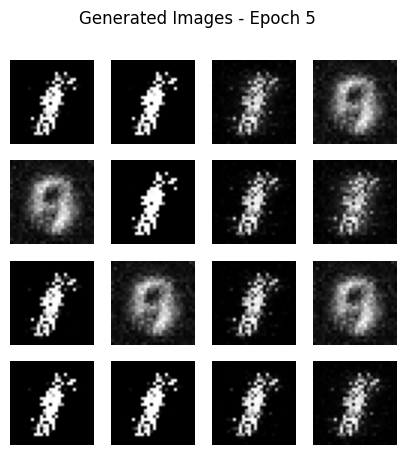

Epoch [6/30] | D Loss: 0.1210 | G Loss: 4.3931
Epoch [7/30] | D Loss: 0.5142 | G Loss: 4.4927
Epoch [8/30] | D Loss: 0.1727 | G Loss: 5.6463
Epoch [9/30] | D Loss: 0.1718 | G Loss: 7.7468
Epoch [10/30] | D Loss: 0.2812 | G Loss: 5.9161


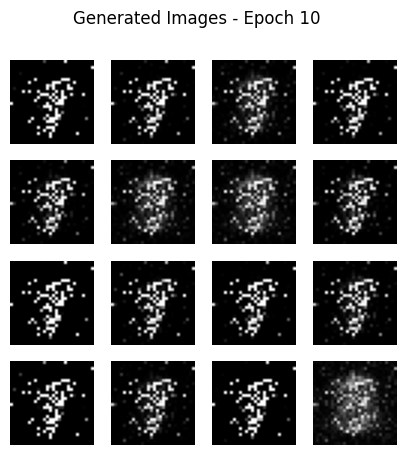

Epoch [11/30] | D Loss: 0.0323 | G Loss: 6.3892
Epoch [12/30] | D Loss: 0.0816 | G Loss: 5.9137
Epoch [13/30] | D Loss: 0.0517 | G Loss: 7.0625
Epoch [14/30] | D Loss: 0.2013 | G Loss: 6.0579
Epoch [15/30] | D Loss: 0.3369 | G Loss: 4.9428


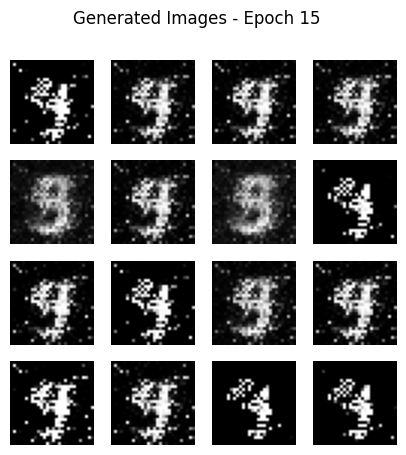

Epoch [16/30] | D Loss: 0.2902 | G Loss: 3.7684
Epoch [17/30] | D Loss: 0.6197 | G Loss: 3.8607
Epoch [18/30] | D Loss: 0.8001 | G Loss: 3.0737
Epoch [19/30] | D Loss: 0.6446 | G Loss: 4.1846
Epoch [20/30] | D Loss: 0.2667 | G Loss: 3.2222


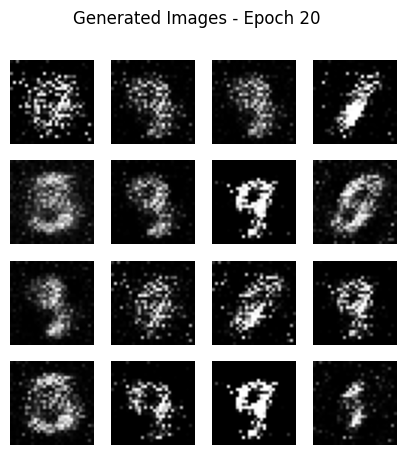

Epoch [21/30] | D Loss: 0.6488 | G Loss: 2.0879
Epoch [22/30] | D Loss: 0.3013 | G Loss: 3.9147
Epoch [23/30] | D Loss: 0.2697 | G Loss: 3.7822
Epoch [24/30] | D Loss: 0.4584 | G Loss: 2.6548
Epoch [25/30] | D Loss: 0.4429 | G Loss: 3.1482


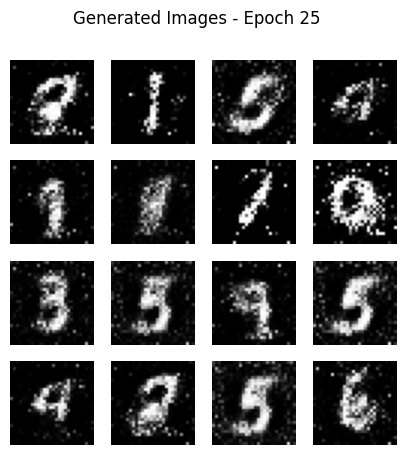

Epoch [26/30] | D Loss: 0.3437 | G Loss: 2.9534
Epoch [27/30] | D Loss: 0.4955 | G Loss: 2.6104
Epoch [28/30] | D Loss: 0.5988 | G Loss: 3.1193
Epoch [29/30] | D Loss: 0.3311 | G Loss: 3.0315
Epoch [30/30] | D Loss: 0.5359 | G Loss: 2.7501


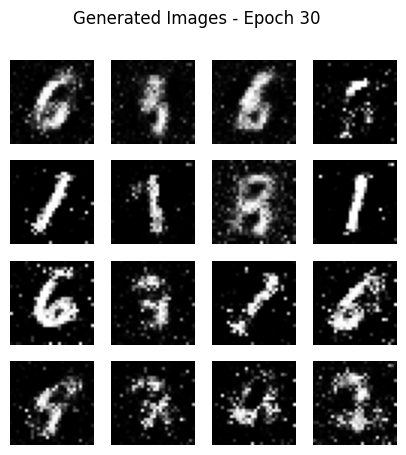

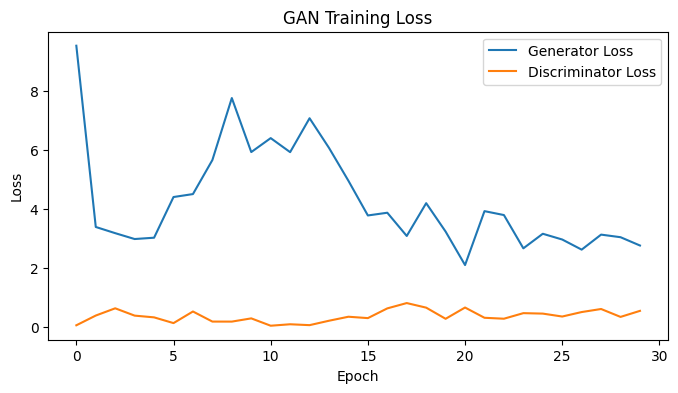

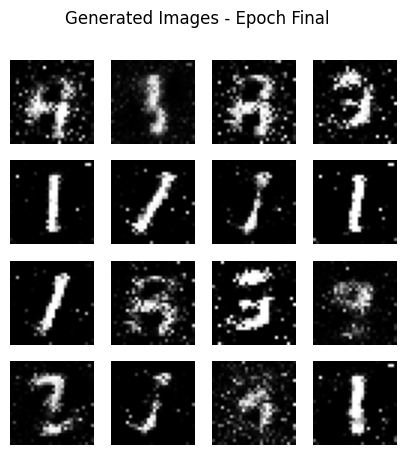

Training completed and models saved.


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

batch_size = 64
latent_dim = 100
lr = 0.0002
epochs = 30
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.ReLU(True),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        output = self.model(z)
        return output.view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img = img.view(img.size(0), -1)
        return self.model(img)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

def show_generated_images(epoch):
    with torch.no_grad():
        noise = torch.randn(16, latent_dim).to(device)
        fake_images = G(noise).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(5,5))

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(fake_images[i][0], cmap='gray')
        ax.axis("off")

    plt.suptitle(f"Generated Images - Epoch {epoch}")
    plt.show()

g_losses = []
d_losses = []

for epoch in range(epochs):

    for real_imgs, _ in loader:

        real_imgs = real_imgs.to(device)
        batch_size_current = real_imgs.size(0)

        real_labels = torch.ones(batch_size_current, 1).to(device)
        fake_labels = torch.zeros(batch_size_current, 1).to(device)

        # =====================
        # Train Discriminator
        # =====================
        optimizer_D.zero_grad()

        real_output = D(real_imgs)
        d_loss_real = criterion(real_output, real_labels)

        noise = torch.randn(batch_size_current, latent_dim).to(device)
        fake_imgs = G(noise)

        fake_output = D(fake_imgs.detach())
        d_loss_fake = criterion(fake_output, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # =====================
        # Train Generator
        # =====================
        optimizer_G.zero_grad()

        fake_output = D(fake_imgs)
        g_loss = criterion(fake_output, real_labels)

        g_loss.backward()
        optimizer_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

    if (epoch + 1) % 5 == 0:
        show_generated_images(epoch + 1)

plt.figure(figsize=(8,4))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("GAN Training Loss")
plt.show()

show_generated_images("Final")

torch.save(G.state_dict(), "generator.pth")
torch.save(D.state_dict(), "discriminator.pth")

print("Training completed and models saved.")